
# Step 1 – Choose a Data Source
> Add blockquote



Disease Risk Prediction Dataset – Kaggle

#Step 2 – Describe Your Dataset

Create a short document answering the following:
1. What is your data source?

    Our data source is the Disease Risk Prediction Dataset available on Kaggle.

2. Why did you choose it?

    We chose this dataset because it is healthcare-related, easy to understand, and useful for data cleaning and analysis.

3. What information does it contain?

    It contains health-related information about individuals that can be used to analyze and predict disease risk.

4. Is it structured, semi-structured, or unstructured?

    It is structured data because it is organized into rows and columns.

5. What format is the data?

    The dataset is available in CSV format.

6. How frequently is the data updated?

    It is a downloadable Kaggle dataset and does not have a fixed automatic update frequency, updates depend on the dataset creator.

#Step 3 – Design Your ETL Pipeline


*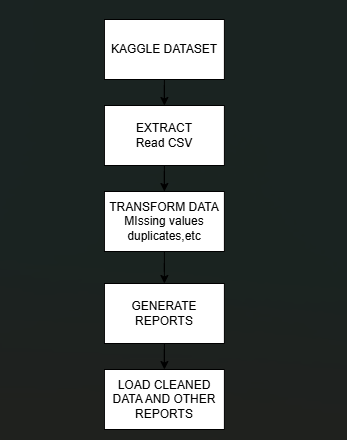

#Step 4 – Create the Project Structure

In [ ]:
import pandas as pd
import os



#Step 5 – Build the Extract Function

In [ ]:
# EXTRACT
def extract():
  raw_data=pd.read_csv('/content/diesease_prediction/raw_data/synthetic_disease_risk_dataset.csv')
  print(raw_data.shape)
  return raw_data

#Step 6 – Build the Transform Function

In [ ]:
# TRANSFORM
def transform(data):

  #check duplicates
  print(data.duplicated().sum())
  # no duplicates

  # Missing values
  print(data.isna().sum())    # here 2 columns have missing values
  # in alcohol consumption none values represent no consumption
  # in previous diagnosis none values represent no previous diagnosis
  data["Alcohol_Consumption"] = data["Alcohol_Consumption"].fillna("no ")
  data["Previous_Diagnosis"] = data["Previous_Diagnosis"].fillna("not diagnosed")
  print(data.isna().sum())
  # check datatype mismatch
  print(data.info())  # no mismatch
  # sorting in order of age
  data = data.sort_values(by="Age", ascending=True)
  print(data.describe())
  print(data.head())
  return data

#Step 8 – Load

In [ ]:
def load(clean_data,summary,risk_report):
  file_path='/content/diesease_prediction/report/cleaned_data.csv'
  if not os.path.exists(file_path):
    clean_data.to_csv(file_path,mode='w',header=True,index=False)
  else:
    clean_data.to_csv(file_path,mode='a',header=True,index=False)
  print('cleaned_Data stored successfully')
  risk_report.to_csv("/content/diesease_prediction/report/Risk_report.csv", index=False)
  print('risk_report stored successfully')
  summary.to_csv("/content/diesease_prediction/report/summary_data.csv")
  print('summary_data stored successfully')



#Step 9 – Build the Pipeline

In [ ]:
def run_pipeline():
  data=extract()
  clean_data=transform(data)
  summary = data.describe()
  risk_report = data["Disease_Risk"].value_counts().reset_index()
  risk_report.columns = ["Disease_Risk", "Patient_Count"]
  load(clean_data,summary,risk_report)

In [ ]:
run_pipeline()

(4000, 15)
0
Patient_ID                     0
Age                            0
Gender                         0
BMI                            0
Smoking_Status                 0
Alcohol_Consumption         1639
Physical_Activity_Level        0
Blood_Pressure_Systolic        0
Blood_Pressure_Diastolic       0
Cholesterol_Level              0
Glucose_Level                  0
Family_History                 0
Genetic_Risk_Score             0
Previous_Diagnosis          2027
Disease_Risk                   0
dtype: int64
Patient_ID                  0
Age                         0
Gender                      0
BMI                         0
Smoking_Status              0
Alcohol_Consumption         0
Physical_Activity_Level     0
Blood_Pressure_Systolic     0
Blood_Pressure_Diastolic    0
Cholesterol_Level           0
Glucose_Level               0
Family_History              0
Genetic_Risk_Score          0
Previous_Diagnosis          0
Disease_Risk                0
dtype: int64
<class 'pandas.c